In [1]:
import numpy as np
import emcee
import corner
import matplotlib.pyplot as plt
np.random.seed(42)
z_bao, bao_val, bao_type = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_mean.txt', unpack=True, dtype=str)
bao_cov = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_cov.txt')
z_bao = z_bao.astype(float)
bao_val = bao_val.astype(float)

# from GPR
mB_match = np.load("output/mB_baomatch_mean_GPR.npy")
mB_cov   = np.load("output/mB_baomatch_cov_GPR.npy")
h_match  = np.load("output/cc_baomatch_mean_GPR.npy")
h_cov    = np.load("output/cc_baomatch_cov_GPR.npy")

# # from GPR but use minimize
# mB_match = np.load("output/mB_baomatch_mean_GPR_minimize.npy")
# mB_cov   = np.load("output/mB_baomatch_cov_GPR_minimize.npy")
# h_match  = np.load("output/cc_baomatch_mean_GPR.npy")
# h_cov    = np.load("output/cc_baomatch_cov_GPR.npy")

# # from FKM
# mB_match = np.load("output/mB_baomatch_mean_FKM.npy")
# mB_cov   = np.load("output/mB_baomatch_cov_FKM.npy")
# h_match  = np.load("output/cc_baomatch_mean_FKM.npy")
# h_cov    = np.load("output/cc_baomatch_cov_FKM.npy")

mask_use = (bao_type == 'DM_over_rs') | (bao_type == 'DV_over_rs')
# mask_use = (bao_type == 'DM_over_rs')

z_fit       = z_bao[mask_use]
bao_val_fit = bao_val[mask_use]
type_fit    = bao_type[mask_use]

idx_fit = np.where(mask_use)[0]
bao_cov_fit = bao_cov[np.ix_(idx_fit, idx_fit)]
mB_cov_fit  = mB_cov[np.ix_(idx_fit, idx_fit)]
h_cov_fit   = h_cov[np.ix_(idx_fit, idx_fit)]

mB_val_fit = mB_match[mask_use]
h_val_fit  = h_match[mask_use]


Running MCMC...


100%|██████████| 5000/5000 [00:08<00:00, 568.61it/s]


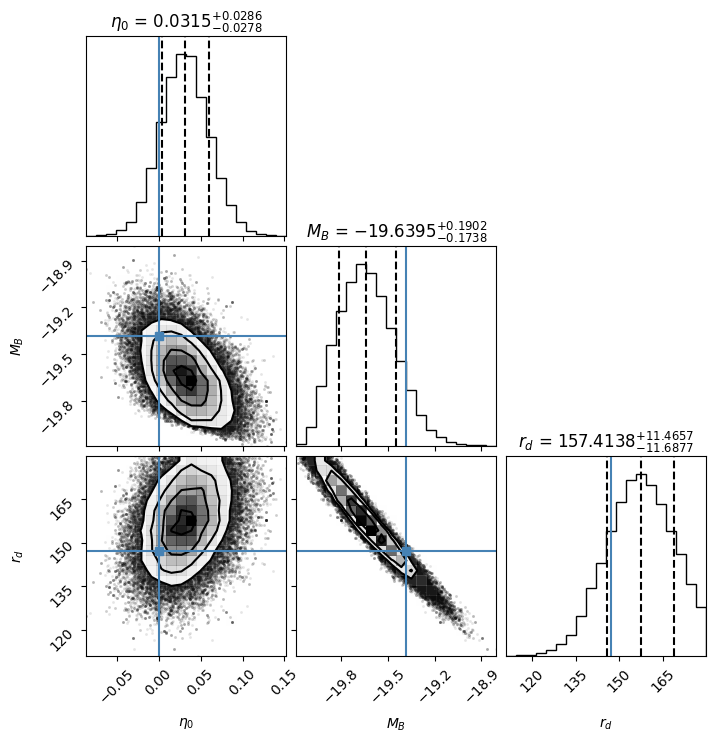

$\eta_0$: 0.0315 (+0.0286 / -0.0278)
$M_B$: -19.6395 (+0.1902 / -0.1738)
$r_d$: 157.4138 (+11.4657 / -11.6877)


In [2]:
import numpy as np
import emcee

def get_eta_th(z, param, model_name):
    if model_name == "linear": return 1.0 + param * z
    if model_name == "fractional": return 1.0 + (param * z) / (1.0 + z)
    if model_name == "logarithmic": return 1.0 + param * np.log(1.0 + z)
    if model_name == "powerlaw": return (1.0 + z)**param

def construct_total_covariance(eta_obs, bao_val, h_val, type_arr, C_mB, C_bao, C_h):
    N, c1 = len(eta_obs), np.log(10) / 5.0
    mask_dm, mask_dv = (type_arr == 'DM_over_rs'), (type_arr == 'DV_over_rs')
    J_mB = np.diag(eta_obs * c1)
    w_b = np.zeros(N)
    w_b[mask_dm], w_b[mask_dv] = -1.0 * eta_obs[mask_dm] / bao_val[mask_dm], -1.5 * eta_obs[mask_dv] / bao_val[mask_dv]
    J_b = np.diag(w_b)
    w_h = np.zeros(N)
    w_h[mask_dv] = -0.5 * eta_obs[mask_dv] / h_val[mask_dv]
    J_h = np.diag(w_h)
    return J_mB @ C_mB @ J_mB + J_b @ C_bao @ J_b + J_h @ C_h @ J_h

def ln_likelihood(theta, z, mB_obs, mB_cov, bao_val, bao_cov, h_val, h_cov, type_arr, model):
    eta_i, MB, rd = theta
    c_l = 299792.458
    DL_s = 10**((mB_obs - MB - 25) / 5.0)
    DM = np.zeros_like(z)
    mask_dm, mask_dv = (type_arr == 'DM_over_rs'), (type_arr == 'DV_over_rs')
    DM[mask_dm] = bao_val[mask_dm] * rd
    DM[mask_dv] = np.sqrt((bao_val[mask_dv]**3 * rd**3 * h_val[mask_dv]) / (z[mask_dv] * c_l))
    eta_obs = DL_s / (DM * (1 + z))
    C = construct_total_covariance(eta_obs, bao_val, h_val, type_arr, mB_cov, bao_cov, h_cov)
    # C += np.eye(len(z)) * 1e-11
    res = eta_obs - get_eta_th(z, eta_i, model)
    try:
        sign, logdet = np.linalg.slogdet(C)
        if sign <= 0: return -np.inf
        return -0.5 * (res @ np.linalg.solve(C, res) + logdet + len(z)*np.log(2*np.pi))
    except np.linalg.LinAlgError: return -np.inf

def ln_prior(theta, prior):
    eta_i, MB, rd = theta
    if not (-0.5 < eta_i < 0.5 and -20.5 < MB < -18.5 and 110 < rd < 180): return -np.inf
    lp = 0.0
    if prior == "P18": lp += -0.5 * ((rd - 147.09) / 0.26)**2
    if prior == "R22": lp += -0.5 * ((MB - (-19.384)) / 0.052)**2
    return lp

def ln_probability(theta, *args):
    lp = ln_prior(theta, args[-1])
    if not np.isfinite(lp): return -np.inf
    return lp + ln_likelihood(theta, *args[:-1])

nwalkers = 32
ndim = 3
p0 = [0.0, -19.38, 147.0] + 1e-3 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, ln_probability, 
    args=(z_fit, mB_val_fit, mB_cov_fit, bao_val_fit, bao_cov_fit, h_val_fit, h_cov_fit, type_fit, "linear", "no prior")
)

print("Running MCMC...")
sampler.run_mcmc(p0, 5000, progress=True)

samples = sampler.get_chain(discard=1000, flat=True)

labels = [r"$\eta_0$", r"$M_B$", r"$r_d$"]
fig = corner.corner(samples, labels=labels, truths=[0.0, -19.384, 147.09], 
                    show_titles=True, quantiles=[0.16, 0.5, 0.84], 
                    title_fmt=".4f")
plt.show()

for i in range(ndim):
    mcmc = np.percentile(samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    print(f"{labels[i]}: {mcmc[1]:.4f} (+{q[1]:.4f} / -{q[0]:.4f})")

In [3]:
models = ["linear", "fractional", "logarithmic", "powerlaw"]
priors = ["noprior","P18", "R22"]

data_args = (z_fit, mB_val_fit, mB_cov_fit, bao_val_fit, bao_cov_fit, h_val_fit, h_cov_fit, type_fit)
for model in models:
    for prior in priors:
        fname = f"chain/samples_{model}_{prior}.npy"
        
        print(f"Running: Model={model}, Prior={prior}")
        nwalkers, ndim = 32, 3
        p0 = [0.0, -19.38, 147.0] + 1e-4 * np.random.randn(nwalkers, ndim)
        sampler = emcee.EnsembleSampler(nwalkers, ndim, ln_probability, args=(*data_args, model, prior))
        sampler.run_mcmc(p0, 5000, progress=True)
        
        samples = sampler.get_chain(discard=1000, flat=True)
        for i in range(ndim):
            mcmc = np.percentile(samples[:, i], [16, 50, 84])
            q = np.diff(mcmc)
            print(f"{labels[i]}: {mcmc[1]:.4f} (+{q[1]:.4f} / -{q[0]:.4f})")
        np.save(fname, samples)

Running: Model=linear, Prior=noprior


100%|██████████| 5000/5000 [00:08<00:00, 559.39it/s]


$\eta_0$: 0.0312 (+0.0290 / -0.0282)
$M_B$: -19.6463 (+0.1920 / -0.1738)
$r_d$: 157.9996 (+11.3495 / -11.8680)
Running: Model=linear, Prior=P18


100%|██████████| 5000/5000 [00:09<00:00, 526.42it/s]


$\eta_0$: 0.0227 (+0.0272 / -0.0265)
$M_B$: -19.4740 (+0.0445 / -0.0450)
$r_d$: 147.0939 (+0.2583 / -0.2553)
Running: Model=linear, Prior=R22


...

$\eta_0$: 0.0652 (+0.0520 / -0.0538)
$M_B$: -19.6819 (+0.2117 / -0.1841)
$r_d$: 158.5539 (+11.5080 / -12.1315)
Running: Model=powerlaw, Prior=P18


100%|██████████| 5000/5000 [00:09<00:00, 524.26it/s]


$\eta_0$: 0.0473 (+0.0508 / -0.0530)
$M_B$: -19.4933 (+0.0626 / -0.0613)
$r_d$: 147.0919 (+0.2591 / -0.2535)
Running: Model=powerlaw, Prior=R22


100%|██████████| 5000/5000 [00:09<00:00, 521.96it/s]

$\eta_0$: 0.0188 (+0.0464 / -0.0447)
$M_B$: -19.4010 (+0.0501 / -0.0507)
$r_d$: 143.3554 (+4.3926 / -4.3696)


In [4]:
import numpy as np
from getdist import MCSamples, plots
prior_labels = [ "No Prior", "R22 Prior", "Planck18 Prior"]
prior_colors = ["#5E75AB", "#A84C4D", "#43623D"]

model_params = {
    "linear": [r"\eta_1", r"M_B", r"r_d"],
    "fractional": [r"\eta_2", r"M_B", r"r_d"],
    "logarithmic": [r"\eta_3", r"M_B", r"r_d"],
    "powerlaw": [r"\epsilon", r"M_B", r"r_d"]
}

for model in models:
    mcsamples_list = []
    
    for i, prior in enumerate(priors):
        # Load samples (shape: [N, 3])
        data = np.load(f"chain/samples_{model}_{prior}.npy")
        
        # Create MCSamples object
        samples = MCSamples(
            samples=data,
            names=["eta", "MB", "rd"],
            labels=model_params[model],
            label=prior_labels[i]
        )
        samples.updateSettings({'smooth_scale_1D': 0.5, 'smooth_scale_2D': 0.5})
        mcsamples_list.append(samples)

    g = plots.get_subplot_plotter(subplot_size=3)
    
    # Plot Triangle
    g.triangle_plot(
        mcsamples_list,
        filled=True,
        contour_colors = prior_colors,
        markers={"eta": 0},
        marker_args={"lw": 1},
    )
    
    g.export(f"fig/constraint_{model}_comparison.pdf")

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
